# Эксперименты с фалами

In [3]:
import xmltodict
import pprint
import json

with open('epi\Эпикриз_1565_v1.xml', 'r', encoding='utf-8') as fd:
    doc = xmltodict.parse(fd.read())


pprint.pprint(doc, indent=4)

{   'ClinicalDocument': {   '@xmlns': 'urn:hl7-org:v3',
                            '@xmlns:xsi': 'http://www.w3.org/2001/XMLSchema-instance',
                            '@xsi:schemaLocation': 'urn:hl7-org:v3 CDA.xsd',
                            'author': {   'assignedAuthor': {'id': None},
                                          'time': None},
                            'code': {   '@code': '10000',
                                        '@codeSystem': '1.2.643.5.1.13.13.11.1115',
                                        '@codeSystemName': 'Система '
                                                           'электронных '
                                                           'медицинских '
                                                           'документов',
                                        '@codeSystemVersion': '2.2',
                                        '@displayName': 'xml_AIDoctor'},
                            'component': {   'structuredBody': {   'compon

## Изучаем содержимое

In [39]:
import xmltodict
import pprint

with open('epi\Эпикриз_22_v1.xml', 'r', encoding='utf-8') as fd:
    doc = xmltodict.parse(fd.read())


print("Основные блоки документа:")
for key in doc.keys():
    print(f"- {key}")


root_key = list(doc.keys())[0]  
print(f"\nКорневой элемент: {root_key}")


if isinstance(doc[root_key], dict):
    print(f"\nПодразделы элемента '{root_key}':")
    for sub_key in doc[root_key].keys():
        print(f"- {sub_key}")
        
print(doc['ClinicalDocument']['component'])

Основные блоки документа:
- ClinicalDocument

Корневой элемент: ClinicalDocument

Подразделы элемента 'ClinicalDocument':
- @xmlns
- @xmlns:xsi
- @xsi:schemaLocation
- realmCode
- typeId
- id
- code
- title
- effectiveTime
- confidentialityCode
- languageCode
- versionNumber
- recordTarget
- author
- custodian
- component
{'structuredBody': {'component': [{'section': {'code': {'@code': 'DGN', '@codeSystem': '1.2.643.5.1.13.13.99.2.197', '@codeSystemName': 'Секции электронных медицинских документов', '@codeSystemVersion': '3.7', '@displayName': 'Диагнозы'}, 'title': 'ДИАГНОЗЫ ПАЦИЕНТА', 'text': {'br': None, 'table': {'tbody': {'tr': [{'td': ['Шифр', 'Тип', 'Текст']}, {'td': ['J15.9', 'Основное заболевание', None]}]}}, '#text': 'Заключительный клинический диагноз'}, 'entry': {'act': {'@classCode': 'ACT', '@moodCode': 'EVN', 'code': {'@code': '3', '@codeSystem': '1.2.643.5.1.13.13.11.1076', '@codeSystemName': 'Степень обоснованности диагноза', '@codeSystemVersion': '1.2', '@displayName': 

# Смотрим количество секций

In [5]:
import os
import tqdm as td
# Указываем путь к директории
directory = "epi"
 
# Получаем список файлов
files = os.listdir(directory)
print(files)
print(len(files))

min = 1000
max =-1000
mean=0
col=0
sum=0
leng=0
 #for i in tqdm(range(100), ncols=80, ascii=True, desc='Total'):
for i in td.tqdm(range(len(files)-1)):
    with open('epi/'+str(files[i]), 'r', encoding='utf-8') as fd:
        doc = xmltodict.parse(fd.read())
    leng =len(doc['ClinicalDocument']['component']['structuredBody']['component'])
    if (leng>max):
        print(leng)
        print("max change")
        max=leng
    if(leng<min):
        min=leng
    col=col+1
    sum=sum+leng
print(min)
print(max)
print(sum/col)


['Эпикриз_100263_v1.xml', 'Эпикриз_100267_v1.xml', 'Эпикриз_100573_v1.xml', 'Эпикриз_10491_v1.xml', 'Эпикриз_10751_v1.xml', 'Эпикриз_10761_v1.xml', 'Эпикриз_10771_v1.xml', 'Эпикриз_10781_v1.xml', 'Эпикриз_10791_v1.xml', 'Эпикриз_10801_v1.xml', 'Эпикриз_10811_v1.xml', 'Эпикриз_10821_v1.xml', 'Эпикриз_10841_v1.xml', 'Эпикриз_10871_v1.xml', 'Эпикриз_11041_v1.xml', 'Эпикриз_11071_v1.xml', 'Эпикриз_11231_v1.xml', 'Эпикриз_11391_v1.xml', 'Эпикриз_1502_v1.xml', 'Эпикриз_1503_v1.xml', 'Эпикриз_1504_v1.xml', 'Эпикриз_1505_v1.xml', 'Эпикриз_1508_v1.xml', 'Эпикриз_1510_v1.xml', 'Эпикриз_1511_v1.xml', 'Эпикриз_1512_v1.xml', 'Эпикриз_1513_v1.xml', 'Эпикриз_1514_v1.xml', 'Эпикриз_1515_v1.xml', 'Эпикриз_1517_v1.xml', 'Эпикриз_1523_v1.xml', 'Эпикриз_1525_v1.xml', 'Эпикриз_1527_v1.xml', 'Эпикриз_1528_v1.xml', 'Эпикриз_1529_v1.xml', 'Эпикриз_1549_v1.xml', 'Эпикриз_1550_v1.xml', 'Эпикриз_1551_v1.xml', 'Эпикриз_1552_v1.xml', 'Эпикриз_1553_v1.xml', 'Эпикриз_1554_v1.xml', 'Эпикриз_1555_v1.xml', 'Эпикриз_155

  1%|          | 11/2027 [00:00<00:19, 105.82it/s]

10
max change


 13%|█▎        | 266/2027 [00:02<00:17, 100.80it/s]


KeyboardInterrupt: 

In [169]:
#print(doc['ClinicalDocument']['component']['structuredBody']['component'])
#pprint.pprint(doc, indent=4)

new_doc=doc['ClinicalDocument']['component']['structuredBody']['component']
#Диагноз пациента
print(new_doc[0]['section']['title'])
print(new_doc[0]['section']['entry']['act']['entryRelationship']['observation']['value']['@displayName'])
print(new_doc[0]['section']['text']['table']['tbody']['tr'][1]['td'][0])
print("\n")
#Жалобы пациенты
print(new_doc[1]['section']['title'])
print(new_doc[1]['section']['text']['#text'])
print("\n")

#Социальный анамнез
print(new_doc[2]['section']['title'])
print(new_doc[2]['section']['text']['list'][0]['item']['content']['#text'])
print(new_doc[2]['section']['text']['list'][1]['item']['content']['#text'])
print(new_doc[2]['section']['text']['list'][2]['item']['content']['#text'])
print(new_doc[2]['section']['text']['list'][3]['item']['content']['#text'])
print("\n")
#Анамнез заболевания
print(new_doc[3]['section']['title'])
print(new_doc[3]['section']['text'])
print("\n")

#Физикальное обследование
print(new_doc[4]['section']['title'])
print(new_doc[4]['section']['entry']['observation']['value']['#text'])
print("\n")

#ОБЪЕКТИВИЗИРОВАННАЯ ОЦЕНКА СОСТОЯНИЯ БОЛЬНОГО

# чёт не любят сюда записывать
#print(new_doc[6]['section'])

#Патологические реакции
# Нет ифнормации
#print(new_doc[7]['section'])

# Витальные параметры
print(new_doc[8]['section']['title'])
print(new_doc[8]['section']['entry'][0]['organizer']['component']['observation']['code']['@displayName'])
print(new_doc[8]['section']['entry'][0]['organizer']['component']['observation']['value']['@value'])
print(new_doc[8]['section']['entry'][1]['organizer']['component']['observation']['code']['@displayName'])
print(new_doc[8]['section']['entry'][1]['organizer']['component']['observation']['value']['@value'])
print(new_doc[8]['section']['entry'][2]['organizer']['component']['observation']['code']['@displayName'])
print(new_doc[8]['section']['entry'][2]['organizer']['component']['observation']['value']['@value'])
print(new_doc[8]['section']['entry'][3]['organizer']['component']['observation']['code']['@displayName'])
print(new_doc[8]['section']['entry'][3]['organizer']['component']['observation']['value']['@value'])
print(new_doc[8]['section']['entry'][4]['organizer']['component']['observation']['code']['@displayName'])
print(new_doc[8]['section']['entry'][4]['organizer']['component']['observation']['value']['@value'])
print(new_doc[8]['section']['entry'][5]['organizer']['component']['observation']['code']['@displayName'])
print(new_doc[8]['section']['entry'][5]['organizer']['component']['observation']['value']['@value'])
print(new_doc[8]['section']['entry'][6]['organizer']['component']['observation']['code']['@displayName'])
print(new_doc[8]['section']['entry'][6]['organizer']['component']['observation']['value']['@value'])
print(new_doc[8]['section']['entry'][7]['organizer']['component']['observation']['code']['@displayName'])
print(new_doc[8]['section']['entry'][7]['organizer']['component']['observation']['value']['@value'])
print("\n")

#ДИАГНОСТИЧЕСКИЕ ИССЛЕДОВАНИЯ И КОНСУЛЬТАЦИИ
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['title'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][0]['section']['text']['table']['tbody']['tr'][1]['td'][1])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][0]['section']['text']['table']['tbody']['tr'][1]['td'][2])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][0]['section']['text']['table']['tbody']['tr'][2]['td'][1])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][0]['section']['text']['table']['tbody']['tr'][2]['td'][2])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][0]['tbody']['tr'][1]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][0]['tbody']['tr'][2]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][0]['tbody']['tr'][3]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][1]['tbody']['tr'][1]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][1]['tbody']['tr'][2]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][2]['tbody']['tr'][1]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][2]['tbody']['tr'][2]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][2]['tbody']['tr'][3]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][2]['tbody']['tr'][4]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][2]['tbody']['tr'][5]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][2]['tbody']['tr'][6]['td'])
print(doc['ClinicalDocument']['component']['structuredBody']['component'][9]['section']['component'][1]['section']['text']['table'][3]['tbody']['tr'][1]['td'])

ДИАГНОЗЫ ПАЦИЕНТА
Бактериальная пневмония неуточненная
J15.9


ЖАЛОБЫ ПРИ ПОСТУПЛЕНИИ
СостояниеЖ Средней тяжести.                  Жалобы: на повышение температуры тела до 38,0, кашель сухой, общая слабость


СОЦИАЛЬНЫЙ АНАМНЕЗ
Неработающий
1 группа
Село
Инвалиды I группы


Анамнез заболевания
Заболел 3 дня назад, когда появилась субфебрильная температура, общая слабость. Самостоятельно принимал терафлекс. Состояние с отрицательной динамикой, повышение температуры тела до 38,0, кашель сухой. Обратился в поликлинику по м/ж, выполнена МСКТ ОГК: 2-сторонняя полисегментарная пневмония.С 9 лет Сахарный диабет 1 типа, ЦУГГ менее 8%. На инсулинотерапии. С 2019 г программный гемодиализ по поводу диабетической нефропатии в стадии почечной недостаточности. ХБП С5Д. Симптоматическая (нефрогенная) артериальная гипертензия, 3 стадии, риск 4. ХСН с промежуточной ФВ 46% ХСН 2А ФК2.


ФИЗИКАЛЬНОЕ ОБСЛЕДОВАНИЕ
Тяжесть состояния пациента : средней степени тяжести
Уровень сознания по шкале Глазго : ясное

# Релиз парсинга

In [9]:
import os
import json
import xmltodict
import tqdm as td

# Указываем путь к директории
directory = "epi"

files = os.listdir(directory)
print(f"Найдено файлов: {len(files)}")

def safe_get(data, keys, default=None):
    """Рекурсивно получает значение из словаря по цепочке ключей"""
    if isinstance(keys, str):
        keys = [keys]
    
    current = data
    for key in keys:
        if isinstance(current, dict) and key in current:
            current = current[key]
        elif isinstance(current, list) and isinstance(key, int) and key < len(current):
            current = current[key]
        else:
            return default
    return current

# Создаем папку для результатов
output_dir = "json_results"
os.makedirs(output_dir, exist_ok=True)

# Обработка всех файлов
for i in td.tqdm(range(len(files)), ncols=80, ascii=True, desc='Обработка файлов'):
    file_data = {}
    
    try:
        with open(os.path.join(directory, files[i]), 'r', encoding='utf-8') as fd:
            doc = xmltodict.parse(fd.read())
        
        # Получаем основные компоненты
        new_doc = safe_get(doc, ['ClinicalDocument', 'component', 'structuredBody', 'component'], [])
        
        # Диагноз пациента
        try:
            file_data["diagnosis"] = {
                "title": safe_get(new_doc, [0, 'section', 'title']),
                "display_name": safe_get(new_doc, [0, 'section', 'entry', 'act', 'entryRelationship', 'observation', 'value', '@displayName']),
                "diagnosis_text": safe_get(new_doc, [0, 'section', 'text', 'table', 'tbody', 'tr', 1, 'td', 0])
            }
        except:
            file_data["diagnosis"] = None
        
        # Жалобы пациента
        try:
            file_data["complaints"] = {
                "title": safe_get(new_doc, [1, 'section', 'title']),
                "text": safe_get(new_doc, [1, 'section', 'text', '#text'])
            }
        except:
            file_data["complaints"] = None
        
        # Социальный анамнез
        try:
            social_data = {
                "title": safe_get(new_doc, [2, 'section', 'title'])
            }
            
            # Обрабатываем список социальных данных
            social_items = []
            for j in range(4):  # 4 элемента как в примере
                item_text = safe_get(new_doc, [2, 'section', 'text', 'list', j, 'item', 'content', '#text'])
                if item_text:
                    social_items.append(item_text)
            
            social_data["items"] = social_items if social_items else None
            file_data["social_history"] = social_data
        except:
            file_data["social_history"] = None
        
        # Анамнез заболевания
        try:
            file_data["disease_history"] = {
                "title": safe_get(new_doc, [3, 'section', 'title']),
                "text": safe_get(new_doc, [3, 'section', 'text'])
            }
        except:
            file_data["disease_history"] = None
        
        # Физикальное обследование
        try:
            file_data["physical_examination"] = {
                "title": safe_get(new_doc, [4, 'section', 'title']),
                "value": safe_get(new_doc, [4, 'section', 'entry', 'observation', 'value', '#text'])
            }
        except:
            file_data["physical_examination"] = None
        
        # Витальные параметры
        try:
            vital_data = {
                "title": safe_get(new_doc, [8, 'section', 'title'])
            }
            
            vital_params = []
            for k in range(8):  # 8 параметров как в примере
                param_name = safe_get(new_doc, [8, 'section', 'entry', k, 'organizer', 'component', 'observation', 'code', '@displayName'])
                param_value = safe_get(new_doc, [8, 'section', 'entry', k, 'organizer', 'component', 'observation', 'value', '@value'])
                
                if param_name or param_value:
                    vital_params.append({
                        "name": param_name,
                        "value": param_value
                    })
            
            vital_data["parameters"] = vital_params if vital_params else None
            file_data["vital_signs"] = vital_data
        except:
            file_data["vital_signs"] = None
        
        # ДИАГНОСТИЧЕСКИЕ ИССЛЕДОВАНИЯ И КОНСУЛЬТАЦИИ
        try:
            diagnostics_data = {
                "title": safe_get(new_doc, [9, 'section', 'title'])
            }
            
            # Данные из первого компонента (таблицы)
            diagnostic_results = []
            
            # Первая таблица - строки 1 и 2
            try:
                diagnostic_results.append({
                    "source": "component_0_table_1",
                    "row_1_td_1": safe_get(new_doc, [9, 'section', 'component', 0, 'section', 'text', 'table', 'tbody', 'tr', 1, 'td', 1]),
                    "row_1_td_2": safe_get(new_doc, [9, 'section', 'component', 0, 'section', 'text', 'table', 'tbody', 'tr', 1, 'td', 2]),
                    "row_2_td_1": safe_get(new_doc, [9, 'section', 'component', 0, 'section', 'text', 'table', 'tbody', 'tr', 2, 'td', 1]),
                    "row_2_td_2": safe_get(new_doc, [9, 'section', 'component', 0, 'section', 'text', 'table', 'tbody', 'tr', 2, 'td', 2])
                })
            except:
                pass
            
            # Второй компонент - несколько таблиц
            try:
                # Таблица 0
                table_0_data = []
                for row_idx in [1, 2, 3]:
                    cell_value = safe_get(new_doc, [9, 'section', 'component', 1, 'section', 'text', 'table', 0, 'tbody', 'tr', row_idx, 'td'])
                    if cell_value:
                        table_0_data.append({
                            f"row_{row_idx}": cell_value
                        })
                
                if table_0_data:
                    diagnostic_results.append({
                        "source": "component_1_table_0",
                        "data": table_0_data
                    })
            except:
                pass
            
            try:
                # Таблица 1
                table_1_data = []
                for row_idx in [1, 2]:
                    cell_value = safe_get(new_doc, [9, 'section', 'component', 1, 'section', 'text', 'table', 1, 'tbody', 'tr', row_idx, 'td'])
                    if cell_value:
                        table_1_data.append({
                            f"row_{row_idx}": cell_value
                        })
                
                if table_1_data:
                    diagnostic_results.append({
                        "source": "component_1_table_1",
                        "data": table_1_data
                    })
            except:
                pass
            
            try:
                # Таблица 2
                table_2_data = []
                for row_idx in [1, 2, 3, 4, 5, 6]:
                    cell_value = safe_get(new_doc, [9, 'section', 'component', 1, 'section', 'text', 'table', 2, 'tbody', 'tr', row_idx, 'td'])
                    if cell_value:
                        table_2_data.append({
                            f"row_{row_idx}": cell_value
                        })
                
                if table_2_data:
                    diagnostic_results.append({
                        "source": "component_1_table_2",
                        "data": table_2_data
                    })
            except:
                pass
            
            try:
                # Таблица 3
                table_3_data = []
                cell_value = safe_get(new_doc, [9, 'section', 'component', 1, 'section', 'text', 'table', 3, 'tbody', 'tr', 1, 'td'])
                if cell_value:
                    table_3_data.append({
                        "row_1": cell_value
                    })
                
                if table_3_data:
                    diagnostic_results.append({
                        "source": "component_1_table_3",
                        "data": table_3_data
                    })
            except:
                pass
            
            diagnostics_data["results"] = diagnostic_results if diagnostic_results else None
            file_data["diagnostic_studies"] = diagnostics_data
        except:
            file_data["diagnostic_studies"] = None

        # Сохраняем в JSON файл
        output_filename = os.path.splitext(files[i])[0] + '.json'
        output_path = os.path.join(output_dir, output_filename)
        
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(file_data, f, ensure_ascii=False, indent=2)
        
    except Exception as e:
        print(f"\nОшибка при обработке файла {files[i]}: {str(e)}")
        
        # Сохраняем файл с ошибкой
        error_data = {
            "error": str(e),
            "filename": files[i]
        }
        output_filename = os.path.splitext(files[i])[0] + '_error.json'
        output_path = os.path.join(output_dir, output_filename)
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(error_data, f, ensure_ascii=False, indent=2)

print(f"\nОбработка завершена. Результаты сохранены в папку '{output_dir}'")

Найдено файлов: 2028


Обработка файлов: 100%|#####################| 2028/2028 [00:21<00:00, 94.72it/s]


Обработка завершена. Результаты сохранены в папку 'json_results'


## Достаём чисто числовые параметры

In [8]:
import json
import os
import re
from typing import Dict, List, Any, Union

def extract_numeric_parameters(data: Dict[str, Any]) -> Dict[str, Any]:
    """
    Извлекает числовые параметры из данных и преобразует их в единый формат
    """
    numeric_params = {}
    
    # 1. Обработка витальных параметров
    if "vital_signs" in data and "parameters" in data["vital_signs"]:
        for param in data["vital_signs"]["parameters"]:
            name = param.get("name")
            value = param.get("value")
            if name and value and is_numeric_value(str(value)):
                try:
                    numeric_value = convert_to_float(str(value))
                    if numeric_value is not None:
                        numeric_params[name] = {
                            "value": numeric_value,
                            "unit": get_unit_from_vital_param(name),
                            "source": "vital_signs"
                        }
                except (ValueError, TypeError):
                    continue
    
    # 2. Обработка диагностических исследований
    if "diagnostic_studies" in data and "results" in data["diagnostic_studies"]:
        for result in data["diagnostic_studies"]["results"]:
            if not result:  # Пропускаем пустые результаты
                continue
                
            if "data" in result and result["data"]:
                for row_data in result["data"]:
                    if not row_data:  # Пропускаем пустые строки
                        continue
                    for row_key, row_item in row_data.items():
                        if (isinstance(row_item, list) and 
                            len(row_item) >= 2 and 
                            row_item[0] and row_item[1] and
                            is_numeric_value(str(row_item[1]))):
                            name = str(row_item[0]).strip()
                            value_str = str(row_item[1]).strip()
                            try:
                                numeric_value = convert_to_float(value_str)
                                if numeric_value is not None:
                                    unit = row_item[2] if len(row_item) > 2 and row_item[2] else None
                                    numeric_params[name] = {
                                        "value": numeric_value,
                                        "unit": unit,
                                        "source": result.get("source", "diagnostic_studies")
                                    }
                            except (ValueError, TypeError):
                                continue
            
            # Обработка данных в формате row_X_td_Y
            elif any(key.startswith('row_') for key in result.keys()):
                for key, value in result.items():
                    if (key.startswith('row_') and key.endswith('_td_2') and 
                        value and is_numeric_value(str(value))):
                        # Ищем соответствующее название параметра
                        param_name_key = key.replace('_td_2', '_td_1')
                        if param_name_key in result and result[param_name_key]:
                            name = str(result[param_name_key]).strip()
                            value_str = str(value).strip()
                            try:
                                numeric_value = convert_to_float(value_str)
                                if numeric_value is not None:
                                    numeric_params[name] = {
                                        "value": numeric_value,
                                        "unit": None,
                                        "source": result.get("source", "diagnostic_studies")
                                    }
                            except (ValueError, TypeError):
                                continue
    
    # 3. Извлечение числовых параметров из физикального обследования
    if "physical_examination" in data and data["physical_examination"] and "value" in data["physical_examination"]:
        physical_text = data["physical_examination"]["value"]
        if physical_text:
            # Ищем числовые значения в тексте физикального обследования
            numeric_patterns = [
                (r"Температура[^\d]*([\d,]+)[^\d]*С?", "Температура тела", "°C"),
                (r"Пульс[^\d]*([\d,]+)", "Пульс", "уд/мин"),
                (r"ЧСС[^\d]*([\d,]+)", "Частота сердечных сокращений", "уд/мин"),
                (r"АД[^\d]*([\d,]+)[^\d]*и[^\d]*([\d,]+)", "Артериальное давление", "мм рт. ст."),
                (r"Сатурация[^\d]*([\d,]+)", "Сатурация", "%"),
                (r"ЧДД[^\d]*([\d,]+)", "Частота дыхательных движений", "дых/мин"),
                (r"Рост[^\d]*([\d,]+)", "Рост", "см"),
                (r"Масса тела[^\d]*([\d,]+)", "Масса тела", "кг")
            ]
            
            for pattern, param_name, unit in numeric_patterns:
                matches = re.findall(pattern, physical_text)
                if matches:
                    try:
                        if param_name == "Артериальное давление" and len(matches[0]) == 2:
                            # Для АД сохраняем оба значения
                            systolic, diastolic = matches[0]
                            systolic_value = convert_to_float(systolic)
                            diastolic_value = convert_to_float(diastolic)
                            if systolic_value is not None and diastolic_value is not None:
                                numeric_params["Артериальное давление систолическое"] = {
                                    "value": systolic_value,
                                    "unit": unit,
                                    "source": "physical_examination"
                                }
                                numeric_params["Артериальное давление диастолическое"] = {
                                    "value": diastolic_value,
                                    "unit": unit, 
                                    "source": "physical_examination"
                                }
                        else:
                            value = matches[0] if isinstance(matches[0], str) else matches[0][0]
                            numeric_value = convert_to_float(value)
                            if numeric_value is not None:
                                numeric_params[param_name] = {
                                    "value": numeric_value,
                                    "unit": unit,
                                    "source": "physical_examination"
                                }
                    except (ValueError, TypeError, IndexError):
                        continue
    
    return numeric_params

def clean_original_data(data: Dict[str, Any]) -> Dict[str, Any]:
    """
    Очищает исходные данные от числовых параметров и удаляет пустые секции
    """
    cleaned_data = data.copy()
    
    # 1. Очищаем vital_signs - полностью удаляем секцию, если она пустая
    if "vital_signs" in cleaned_data:
        # Если в vital_signs есть только числовые параметры, удаляем всю секцию
        if ("parameters" in cleaned_data["vital_signs"] and 
            len(cleaned_data["vital_signs"]["parameters"]) > 0 and
            all(param.get("value") and is_numeric_value(str(param.get("value"))) 
                for param in cleaned_data["vital_signs"]["parameters"] if param.get("value"))):
            del cleaned_data["vital_signs"]
    
    # 2. Очищаем diagnostic_studies - удаляем числовые строки и пустые results
    if "diagnostic_studies" in cleaned_data and "results" in cleaned_data["diagnostic_studies"]:
        new_results = []
        
        for result in cleaned_data["diagnostic_studies"]["results"]:
            if not result:
                continue
                
            # Создаем копию результата для модификации
            cleaned_result = result.copy()
            
            # Обрабатываем data
            if "data" in cleaned_result and cleaned_result["data"]:
                new_data = []
                for row_data in cleaned_result["data"]:
                    if not row_data:
                        continue
                    
                    # Проверяем, содержит ли строка числовое значение
                    contains_numeric = False
                    for row_key, row_item in row_data.items():
                        if (isinstance(row_item, list) and 
                            len(row_item) >= 2 and 
                            row_item[0] and row_item[1] and
                            is_numeric_value(str(row_item[1]))):
                            contains_numeric = True
                            break
                    
                    # Если строка не содержит числовых значений, оставляем ее
                    if not contains_numeric:
                        new_data.append(row_data)
                
                cleaned_result["data"] = new_data
            
            # Очищаем данные в формате row_X_td_Y
            if any(key.startswith('row_') for key in cleaned_result.keys()):
                keys_to_remove = []
                for key in cleaned_result.keys():
                    if (key.startswith('row_') and key.endswith('_td_2') and 
                        cleaned_result[key] and is_numeric_value(str(cleaned_result[key]))):
                        # Удаляем обе колонки (название и значение)
                        param_name_key = key.replace('_td_2', '_td_1')
                        keys_to_remove.extend([key, param_name_key])
                
                for key in keys_to_remove:
                    if key in cleaned_result:
                        del cleaned_result[key]
            
            # Проверяем, остались ли в результате данные
            has_data = False
            for key, value in cleaned_result.items():
                if key != "source" and value:  # source всегда есть, проверяем другие поля
                    if key == "data" and value:  # data не пустой
                        has_data = True
                        break
                    elif key.startswith('row_') and value:  # row_X_td_Y не пустые
                        has_data = True
                        break
            
            # Если в результате остались данные, добавляем его
            if has_data:
                new_results.append(cleaned_result)
        
        # Обновляем results
        cleaned_data["diagnostic_studies"]["results"] = new_results
        
        # Если results пустой, удаляем всю секцию diagnostic_studies
        if not new_results:
            del cleaned_data["diagnostic_studies"]
    
    return cleaned_data

def convert_to_float(value_str: str) -> float:
    """
    Конвертирует строку в float, поддерживая запятые как десятичные разделители
    """
    if not value_str:
        return None
    try:
        # Заменяем запятые на точки для корректного преобразования
        normalized = value_str.replace(',', '.').strip()
        return float(normalized)
    except (ValueError, TypeError):
        return None

def is_numeric_value(value: str) -> bool:
    """
    Проверяет, является ли значение числовым
    """
    if not value or not isinstance(value, str):
        return False
    
    # Убираем пробелы
    cleaned_value = value.strip()
    
    # Проверяем на число (целое, дробное, с точкой или запятой)
    pattern = r'^-?\d*[,.]?\d+$'
    return bool(re.match(pattern, cleaned_value))

def get_unit_from_vital_param(param_name: str) -> str:
    """
    Определяет единицы измерения для витальных параметров
    """
    units_map = {
        "Температура тела": "°C",
        "Артериальное давление диастолическое": "мм рт. ст.",
        "Артериальное давление систолическое": "мм рт. ст.", 
        "Частота сердечных сокращений": "уд/мин",
        "Сатурация": "%",
        "Частота дыхания": "дых/мин",
        "Пульс": "уд/мин",
        "Рост": "см",
        "Масса тела": "кг"
    }
    return units_map.get(param_name, "")

def process_json_file(file_path: str) -> Dict[str, Any]:
    """
    Обрабатывает один JSON файл
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Проверяем, что данные не пустые
        if not data:
            print(f"Файл {file_path} пустой")
            return {}
        
        # Проверяем, есть ли уже numeric_parameters в файле
        if "numeric_parameters" in data:
            print(f"Файл {file_path} уже содержит numeric_parameters, пропускаем")
            return data  # Возвращаем исходные данные без изменений
        
        # Извлекаем числовые параметры
        numeric_parameters = extract_numeric_parameters(data)
        
        # Очищаем исходные данные от числовых параметров и пустых секций
        cleaned_data = clean_original_data(data)
        
        # Сохраняем очищенные данные и добавляем numeric_parameters
        output_data = cleaned_data
        output_data["numeric_parameters"] = numeric_parameters
        
        return output_data
        
    except Exception as e:
        print(f"Ошибка при обработке файла {file_path}: {str(e)}")
        return {}

def process_all_json_files(folder_path: str, output_folder: str = None):
    """
    Обрабатывает все JSON файлы в папке
    """
    if output_folder is None:
        output_folder = folder_path
    
    # Создаем папку для результатов, если ее нет
    os.makedirs(output_folder, exist_ok=True)
    
    processed_files = []
    skipped_files = []
    error_files = []
    
    # Ищем все JSON файлы в папке
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            # Пропускаем уже обработанные файлы
            if filename.startswith('processed_'):
                print(f"Файл {filename} уже обработан, пропускаем")
                skipped_files.append(filename)
                continue
            
            # Обрабатываем файл
            processed_data = process_json_file(file_path)
            
            if processed_data:
                # Сохраняем обработанный файл
                output_filename = f"processed_{filename}"
                output_path = os.path.join(output_folder, output_filename)
                
                try:
                    with open(output_path, 'w', encoding='utf-8') as f:
                        json.dump(processed_data, f, ensure_ascii=False, indent=2)
                    
                    processed_files.append(output_filename)
                    print(f"Обработан файл: {filename}")
                except Exception as e:
                    print(f"Ошибка при сохранении файла {filename}: {e}")
                    error_files.append(filename)
            else:
                error_files.append(filename)
    
    print(f"\nОбработано файлов: {len(processed_files)}")
    print(f"Пропущено файлов: {len(skipped_files)}")
    print(f"Файлов с ошибками: {len(error_files)}")
    
    return processed_files

# Пример использования
if __name__ == "__main__":
    # Укажите путь к папке с JSON файлами
    input_folder = "json_results"
    output_folder = "processed_results"
    
    # Обрабатываем все файлы
    processed_files = process_all_json_files(input_folder, output_folder)

Обработан файл: Эпикриз_100263_v1.json
Обработан файл: Эпикриз_100267_v1.json
Ошибка при обработке файла json_results\Эпикриз_100573_v1.json: 'NoneType' object is not iterable
Ошибка при обработке файла json_results\Эпикриз_10491_v1.json: 'NoneType' object is not iterable
Ошибка при обработке файла json_results\Эпикриз_10751_v1.json: 'NoneType' object is not iterable
Ошибка при обработке файла json_results\Эпикриз_10761_v1.json: 'NoneType' object is not iterable
Ошибка при обработке файла json_results\Эпикриз_10771_v1.json: 'NoneType' object is not iterable
Ошибка при обработке файла json_results\Эпикриз_10781_v1.json: 'NoneType' object is not iterable
Ошибка при обработке файла json_results\Эпикриз_10791_v1.json: 'NoneType' object is not iterable
Обработан файл: Эпикриз_10801_v1.json
Ошибка при обработке файла json_results\Эпикриз_10811_v1.json: 'NoneType' object is not iterable
Обработан файл: Эпикриз_10821_v1.json
Обработан файл: Эпикриз_10841_v1.json
Ошибка при обработке файла json

## Анализ корреляции числовых параметров

In [21]:
import os
import json
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data(folder_path):
    """Загружает и обрабатывает все JSON файлы из папки"""
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    file_data = json.load(f)
                    data.append(file_data)
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
    
    return data

def create_correlation_dataframe(data):
    """Создает DataFrame для анализа корреляций"""
    records = []
    
    for record in data:
        # Извлекаем диагноз
        diagnosis = record.get('diagnosis', {}).get('diagnosis_text', 'Unknown')
        
        # Извлекаем числовые параметры
        numeric_params = record.get('numeric_parameters', {})
        
        # Создаем запись
        record_data = {'diagnosis': diagnosis}
        
        for param_name, param_data in numeric_params.items():
            if isinstance(param_data, dict) and 'value' in param_data:
                record_data[param_name] = param_data['value']
        
        records.append(record_data)
    
    return pd.DataFrame(records)

def shorten_param_name(param_name, max_length=40):
    """Сокращает название параметра для лучшего отображения"""
    abbreviations = {
        'количество в крови методом автоматизированного подсчёта': '',
        'молярная концентрация в сыворотке или плазме крови': '',
        'Артериальное давление': 'АД',
        'систолическое': 'сист',
        'диастолическое': 'диаст',
        'Частота сердечных сокращений': 'ЧСС',
        'Температура тела': 'Темп',
        'Лейкоциты': 'Лейк',
        'Эритроциты': 'Эритр',
        'Креатинин': 'Креат',
        'Калий': 'Калий',
        'Среднее содержание гемоглобина в эритроците': 'Ср.гемоглобин',
        'Частота дыхания': 'ЧД',
        'Сатурация': 'SpO2',
        'Пульс': 'Пульс',
        'в крови': '',
        'методом автоматизированного подсчёта': '',
        'сыворотке или плазме крови': '',
        'молярная концентрация': '',
        'количество': ''
    }
    
    shortened = param_name
    for long, short in abbreviations.items():
        shortened = shortened.replace(long, short)
    
    # Удаляем лишние пробелы
    shortened = ' '.join(shortened.split())
    
    if len(shortened) > max_length:
        shortened = shortened[:max_length-3] + "..."
    
    return shortened.strip()

def find_strong_parameter_correlations(df, threshold=0.7):
    """Находит сильные корреляции между числовыми параметрами"""
    print(f"\n{'='*70}")
    print(f"СИЛЬНЫЕ КОРРЕЛЯЦИИ МЕЖДУ ПАРАМЕТРАМИ (порог: {threshold})")
    print(f"{'='*70}")
    
    # Выбираем только числовые колонки
    numeric_columns = [col for col in df.columns if col != 'diagnosis' and pd.api.types.is_numeric_dtype(df[col])]
    
    if len(numeric_columns) < 2:
        print("Недостаточно числовых параметров для анализа")
        return
    
    # Вычисляем матрицу корреляций
    correlation_matrix = df[numeric_columns].corr()
    
    strong_correlations = []
    
    # Ищем сильные корреляции
    for i in range(len(numeric_columns)):
        for j in range(i+1, len(numeric_columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if not np.isnan(corr_value) and abs(corr_value) >= threshold:
                param1 = shorten_param_name(numeric_columns[i])
                param2 = shorten_param_name(numeric_columns[j])
                
                # Определяем силу корреляции
                if abs(corr_value) >= 0.9:
                    strength = "ОЧЕНЬ ВЫСОКАЯ"
                elif abs(corr_value) >= 0.8:
                    strength = "ВЫСОКАЯ"
                elif abs(corr_value) >= 0.7:
                    strength = "СРЕДНЯЯ"
                else:
                    strength = "СЛАБАЯ"
                
                direction = "положительная" if corr_value > 0 else "отрицательная"
                
                strong_correlations.append({
                    'param1': param1,
                    'param2': param2,
                    'correlation': corr_value,
                    'abs_correlation': abs(corr_value),
                    'strength': strength,
                    'direction': direction
                })
    
    # Сортируем по силе корреляции
    strong_correlations.sort(key=lambda x: x['abs_correlation'], reverse=True)
    
    if not strong_correlations:
        print(f"Не найдено корреляций с коэффициентом >= {threshold}")
        return
    
    print(f"\nНайдено {len(strong_correlations)} сильных корреляций:")
    print(f"{'Параметр 1':<40} {'Параметр 2':<40} {'Корреляция':<10} {'Сила':<15} {'Направление':<15}")
    print("-" * 120)
    
    for corr in strong_correlations:
        print(f"{corr['param1']:<40} {corr['param2']:<40} {corr['correlation']:>9.3f} {corr['strength']:<15} {corr['direction']:<15}")

def find_strong_diagnosis_correlations(df, threshold=0.5):
    """Находит сильные корреляции между диагнозами и параметрами"""
    print(f"\n{'='*70}")
    print(f"СИЛЬНЫЕ КОРРЕЛЯЦИИ: ДИАГНОЗЫ vs ПАРАМЕТРЫ (порог: {threshold})")
    print(f"{'='*70}")
    
    # Получаем уникальные диагнозы
    diagnoses = [d for d in df['diagnosis'].unique() if d != 'Unknown']
    
    if len(diagnoses) == 0:
        print("Нет диагнозов для анализа")
        return
    
    # Получаем числовые параметры
    numeric_columns = [col for col in df.columns if col != 'diagnosis' and pd.api.types.is_numeric_dtype(df[col])]
    
    if len(numeric_columns) == 0:
        print("Нет числовых параметров для анализа")
        return
    
    strong_correlations = []
    
    for diagnosis in diagnoses:
        diagnosis_binary = (df['diagnosis'] == diagnosis).astype(int)
        
        for param in numeric_columns:
            valid_mask = ~df[param].isna() & ~diagnosis_binary.isna()
            valid_count = valid_mask.sum()
            
            if valid_count > 10:  # Минимум 10 наблюдений для надежности
                try:
                    corr, p_value = pointbiserialr(
                        diagnosis_binary[valid_mask], 
                        df.loc[valid_mask, param]
                    )
                    
                    if not np.isnan(corr) and abs(corr) >= threshold and p_value < 0.05:
                        # Определяем силу корреляции
                        if abs(corr) >= 0.7:
                            strength = "ОЧЕНЬ ВЫСОКАЯ"
                        elif abs(corr) >= 0.5:
                            strength = "ВЫСОКАЯ"
                        else:
                            strength = "СРЕДНЯЯ"
                        
                        direction = "положительная" if corr > 0 else "отрицательная"
                        
                        strong_correlations.append({
                            'diagnosis': diagnosis,
                            'parameter': shorten_param_name(param),
                            'correlation': corr,
                            'abs_correlation': abs(corr),
                            'p_value': p_value,
                            'strength': strength,
                            'direction': direction,
                            'n_observations': valid_count
                        })
                except:
                    continue
    
    # Сортируем по силе корреляции
    strong_correlations.sort(key=lambda x: x['abs_correlation'], reverse=True)
    
    if not strong_correlations:
        print(f"Не найдено значимых корреляций с коэффициентом >= {threshold}")
        return
    
    print(f"\nНайдено {len(strong_correlations)} значимых корреляций:")
    print(f"{'Диагноз':<15} {'Параметр':<40} {'Корреляция':<10} {'p-value':<10} {'Сила':<15} {'Направление':<15} {'N':<6}")
    print("-" * 115)
    
    for corr in strong_correlations:
        print(f"{corr['diagnosis']:<15} {corr['parameter']:<40} {corr['correlation']:>9.3f} {corr['p_value']:>9.3f} {corr['strength']:<15} {corr['direction']:<15} {corr['n_observations']:<6}")

def print_correlation_summary(df):
    """Выводит общую статистику по данным"""
    print("ОБЗОР ДАННЫХ:")
    print(f"Всего записей: {len(df)}")
    print(f"Уникальных диагнозов: {len([d for d in df['diagnosis'].unique() if d != 'Unknown'])}")
    
    numeric_columns = [col for col in df.columns if col != 'diagnosis' and pd.api.types.is_numeric_dtype(df[col])]
    print(f"Числовых параметров: {len(numeric_columns)}")
    
    print("\nСписок параметров:")
    for i, param in enumerate(numeric_columns, 1):
        shortened = shorten_param_name(param)
        non_na_count = df[param].notna().sum()
        print(f"  {i:2d}. {shortened:<45} (непустых: {non_na_count})")

def main():
    folder_path = "processed_results"
    
    # Загружаем данные
    print("Загрузка данных...")
    data = load_and_process_data(folder_path)
    print(f"Загружено {len(data)} файлов")
    
    # Создаем DataFrame
    df = create_correlation_dataframe(data)
    print(f"Создан DataFrame с {len(df)} записями")
    
    # Выводим общую статистику
    print_correlation_summary(df)
    
    # 1. Анализ корреляций между параметрами
    find_strong_parameter_correlations(df, threshold=0.7)
    
    # 2. Анализ корреляций между диагнозами и параметрами
    find_strong_diagnosis_correlations(df, threshold=0.5)

if __name__ == "__main__":
    main()

Загрузка данных...
Загружено 2013 файлов
Создан DataFrame с 2013 записями
ОБЗОР ДАННЫХ:
Всего записей: 2013
Уникальных диагнозов: 53
Числовых параметров: 106

Список параметров:
   1. SpO2                                          (непустых: 1983)
   2. ЧСС                                           (непустых: 2005)
   3. Темп                                          (непустых: 2000)
   4. Пульс                                         (непустых: 1829)
   5. ЧД                                            (непустых: 1953)
   6. АД сист                                       (непустых: 1993)
   7. АД диаст                                      (непустых: 1981)
   8. Тромбоциты                                    (непустых: 781)
   9. Скорость оседания эритроцитов по Вест...      (непустых: 692)
  10. Эозинофилы, абсолютное                        (непустых: 314)
  11. C-реактивный белок, массовая концентр...      (непустых: 396)
  12. Мочевина,                                     (непустых: 415)

## Анализ пропусков и выбросов

Загрузка данных...
Загружено 2013 файлов
Создан DataFrame с 2013 записями и 106 числовыми параметрами

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

Всего числовых параметров: 106

Детальная статистика пропусков:
----------------------------------------------------------------------------------------------------
Параметр                                           Всего    Непустых   Пропущено  %       
----------------------------------------------------------------------------------------------------
Протеин C иммунологическим методом в бедной тромбоцитами плазме по отношению к нормальной плазме 2013     1          2012       100.0   
Лактатдегидрогеназа, каталитическая концентрация в сыворотке или плазме крови методом окисления лактата в пируват 2013     1          2012       100.0   
Кислород, парциальное давление, откорректированное по температуре пациента, в венозной крови 2013     1          2012       100.0   
Мочевина, массовая концентрация в сыворотке или плазме крови 2013     1          2012  

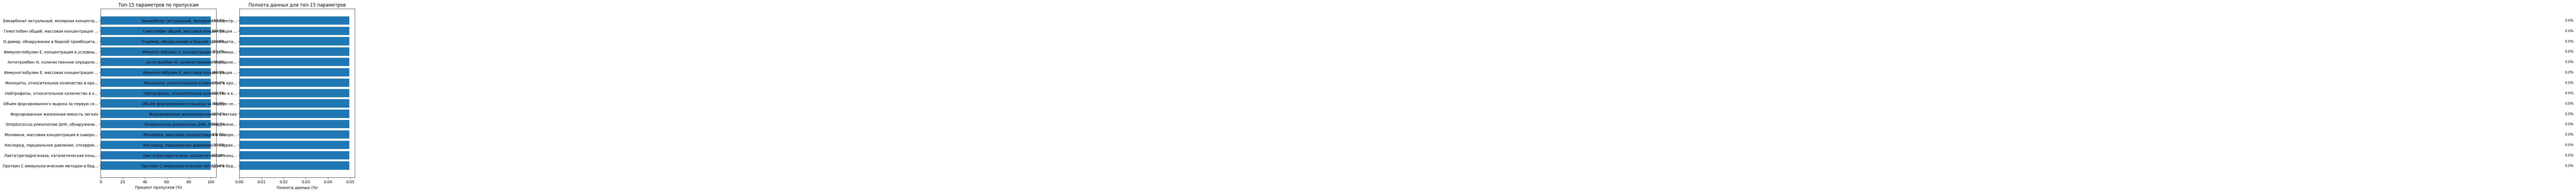


АНАЛИЗ ВЫБРОСОВ

Статистика выбросов (IQR метод):
------------------------------------------------------------------------------------------------------------------------
Параметр                                 Всего  Выбросы  %      Медиана    Min      Max     
------------------------------------------------------------------------------------------------------------------------
Водородный показатель (pH) венозной кр... 6      2        33.3   7.45       4.70     7.47    
Лейкоциты, обнаружение в моче методом ... 89     16       18.0   0.00       0.00     75.00   
Длина тела                               17     3        17.6   165.00     67.00    196.00  
Бикарбонат актуальный, молярная концен... 13     2        15.4   23.70      20.30    33.40   
C-реактивный белок, массовая концентра... 396    57       14.4   13.67      -259.76  398.10  
Нейтрофилы, абсолютное количество в кр... 220    29       13.2   5.60       -3.27    88.10   
Билирубин прямой, молярная концентраци... 8      1 

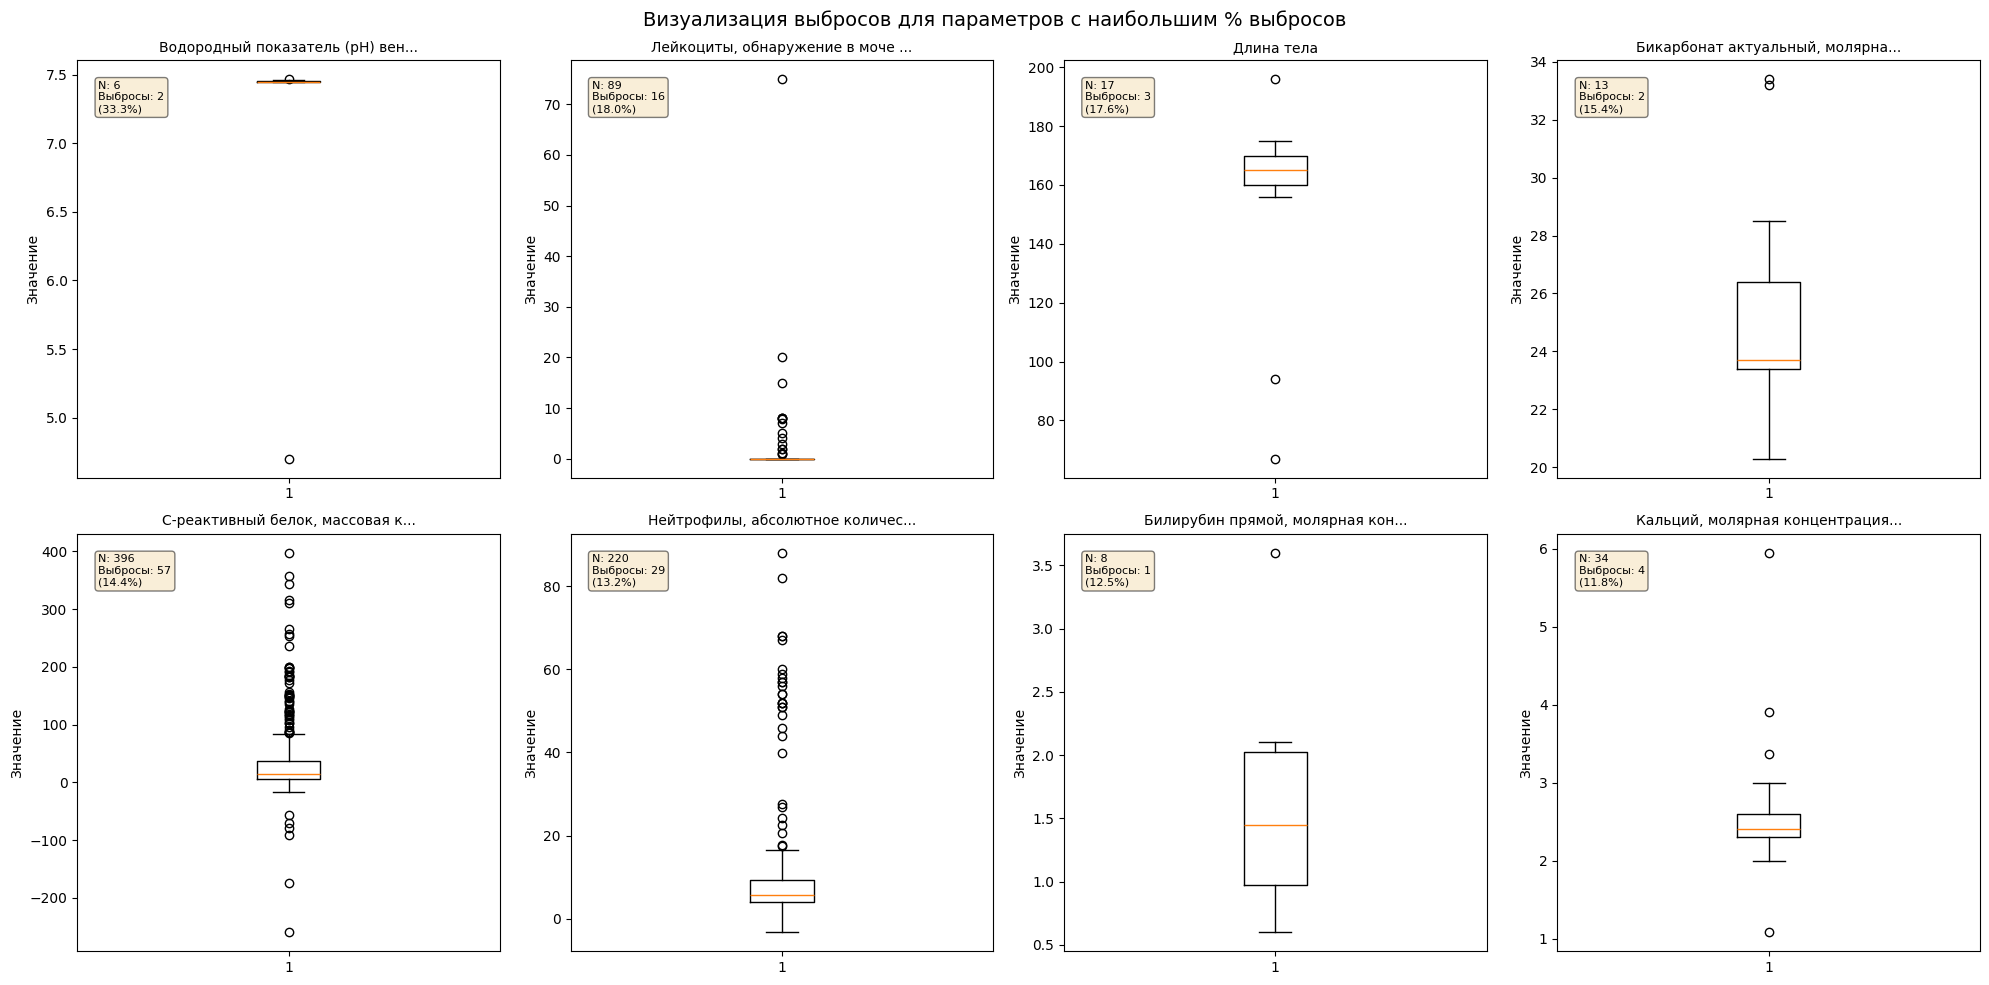


АНАЛИЗ ДИАГНОЗОВ

Всего уникальных диагнозов (diagnosis_text): 53
Всего записей с диагнозами: 2013

Топ-20 самых частых диагнозов:
--------------------------------------------------------------------------------
Код диагноза    Частота    %        Название                                
--------------------------------------------------------------------------------
J44.8           204        10.1     Не указано                              
D14.3           185        9.2      Доброкачественное новообразование брон...
U07.1           167        8.3      COVID-19, вирус идентифицирован         
A15.0           163        8.1      Туберкулез легких, подтвержденный бакт...
C34.1           155        7.7      Злокачественное новообразование верхне...
C34.3           119        5.9      Злокачественное новообразование нижней...
J44.1           118        5.9      Хроническая обструктивная легочная бол...
J15.8           91         4.5      Другие бактериальные пневмонии          
A16.0   

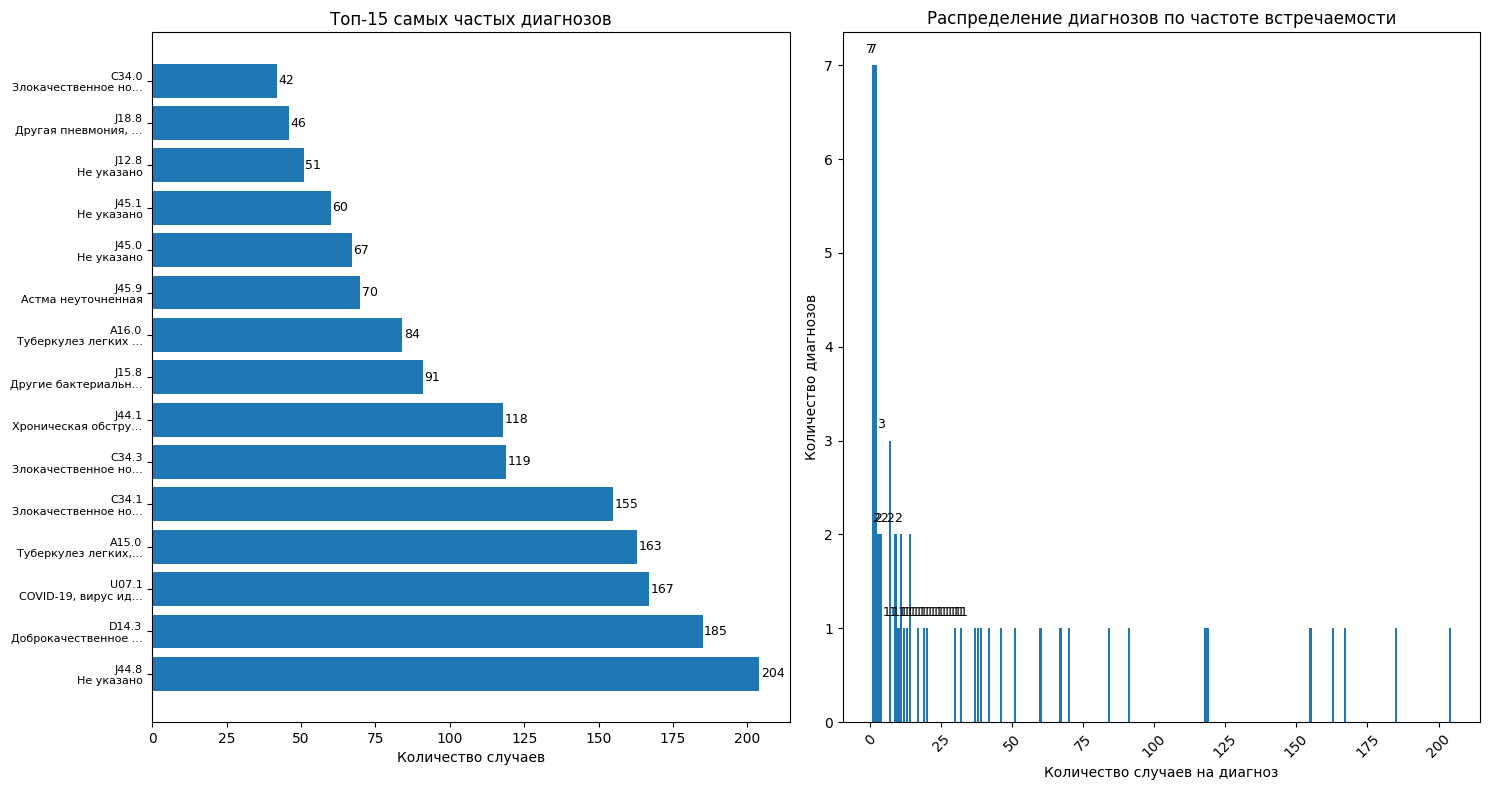


СТАТИСТИКА ПО РЕДКОСТИ ДИАГНОЗОВ:
Диагнозы, встречающиеся только 1 раз: 7 (13.2% от всех уникальных диагнозов)
Диагнозы, встречающиеся > 5 раз: 35 (66.0% от всех уникальных диагнозов)
Среднее количество случаев на диагноз: 38.0
Медианное количество случаев на диагноз: 12.0

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:
Диагнозы с кодом 'Unknown': 3
Диагнозы с пустым кодом: 0


In [23]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def load_and_process_data(folder_path):
    """Загружает и обрабатывает все JSON файлы из папки"""
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    file_data = json.load(f)
                    data.append(file_data)
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
    
    return data

def analyze_missing_values(df):
    """Анализирует пропущенные значения в числовых параметрах"""
    print("\n" + "="*80)
    print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
    print("="*80)
    
    numeric_columns = [col for col in df.columns if col != 'diagnosis' and pd.api.types.is_numeric_dtype(df[col])]
    
    missing_data = []
    
    for column in numeric_columns:
        total_count = len(df)
        non_missing_count = df[column].notna().sum()
        missing_count = total_count - non_missing_count
        missing_percentage = (missing_count / total_count) * 100
        
        missing_data.append({
            'Параметр': column,
            'Всего записей': total_count,
            'Непустых': non_missing_count,
            'Пропущено': missing_count,
            'Пропущено %': missing_percentage
        })
    
    missing_df = pd.DataFrame(missing_data)
    
    # Сортируем по проценту пропусков
    missing_df = missing_df.sort_values('Пропущено %', ascending=False)
    
    print(f"\nВсего числовых параметров: {len(numeric_columns)}")
    print(f"\nДетальная статистика пропусков:")
    print("-" * 100)
    print(f"{'Параметр':<50} {'Всего':<8} {'Непустых':<10} {'Пропущено':<10} {'%':<8}")
    print("-" * 100)
    
    for _, row in missing_df.iterrows():
        print(f"{row['Параметр']:<50} {row['Всего записей']:<8} {row['Непустых']:<10} {row['Пропущено']:<10} {row['Пропущено %']:<8.1f}")
    
    # Визуализация пропусков
    plt.figure(figsize=(12, 8))
    
    # Берем топ-15 параметров по количеству пропусков
    top_missing = missing_df.head(15)
    
    plt.subplot(1, 2, 1)
    bars = plt.barh(range(len(top_missing)), top_missing['Пропущено %'])
    plt.yticks(range(len(top_missing)), [x[:40] + '...' if len(x) > 40 else x for x in top_missing['Параметр']])
    plt.xlabel('Процент пропусков (%)')
    plt.title('Топ-15 параметров по пропускам')
    
    # Добавляем значения на столбцы
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{top_missing.iloc[i]["Пропущено %"]:.1f}%', 
                ha='left', va='center', fontsize=9)
    
    plt.subplot(1, 2, 2)
    completeness = [100 - row['Пропущено %'] for _, row in top_missing.iterrows()]
    bars = plt.barh(range(len(top_missing)), completeness)
    plt.yticks(range(len(top_missing)), [x[:40] + '...' if len(x) > 40 else x for x in top_missing['Параметр']])
    plt.xlabel('Полнота данных (%)')
    plt.title('Полнота данных для топ-15 параметров')
    
    # Добавляем значения на столбцы
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{completeness[i]:.1f}%', 
                ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return missing_df

def analyze_outliers(df):
    """Анализирует выбросы в числовых параметрах"""
    print("\n" + "="*80)
    print("АНАЛИЗ ВЫБРОСОВ")
    print("="*80)
    
    numeric_columns = [col for col in df.columns if col != 'diagnosis' and pd.api.types.is_numeric_dtype(df[col])]
    
    outlier_data = []
    
    for column in numeric_columns:
        # Убираем пропуски
        clean_data = df[column].dropna()
        
        if len(clean_data) < 5:  # Слишком мало данных для анализа
            continue
            
        # Вычисляем статистики
        Q1 = clean_data.quantile(0.25)
        Q3 = clean_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Находим выбросы
        outliers = clean_data[(clean_data < lower_bound) | (clean_data > upper_bound)]
        outlier_percentage = (len(outliers) / len(clean_data)) * 100
        
        # Z-score метод
        z_scores = np.abs(stats.zscore(clean_data))
        z_outliers = clean_data[z_scores > 3]
        z_outlier_percentage = (len(z_outliers) / len(clean_data)) * 100
        
        outlier_data.append({
            'Параметр': column,
            'Всего значений': len(clean_data),
            'Медиана': clean_data.median(),
            'Среднее': clean_data.mean(),
            'Стандартное отклонение': clean_data.std(),
            'IQR выбросы': len(outliers),
            'IQR выбросы %': outlier_percentage,
            'Z-score выбросы': len(z_outliers),
            'Z-score выбросы %': z_outlier_percentage,
            'Min': clean_data.min(),
            'Max': clean_data.max()
        })
    
    outlier_df = pd.DataFrame(outlier_data)
    
    if outlier_df.empty:
        print("Недостаточно данных для анализа выбросов")
        return None
    
    # Сортируем по проценту выбросов (IQR метод)
    outlier_df = outlier_df.sort_values('IQR выбросы %', ascending=False)
    
    print(f"\nСтатистика выбросов (IQR метод):")
    print("-" * 120)
    print(f"{'Параметр':<40} {'Всего':<6} {'Выбросы':<8} {'%':<6} {'Медиана':<10} {'Min':<8} {'Max':<8}")
    print("-" * 120)
    
    for _, row in outlier_df.iterrows():
        print(f"{row['Параметр'][:38] + '...' if len(row['Параметр']) > 40 else row['Параметр']:<40} "
              f"{row['Всего значений']:<6} {row['IQR выбросы']:<8} {row['IQR выбросы %']:<6.1f} "
              f"{row['Медиана']:<10.2f} {row['Min']:<8.2f} {row['Max']:<8.2f}")
    
    # Визуализация выбросов для топ параметров
    top_outlier_params = outlier_df.head(8)['Параметр'].tolist()
    
    if top_outlier_params:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()
        
        for i, param in enumerate(top_outlier_params):
            if i < len(axes):
                clean_data = df[param].dropna()
                
                # Box plot
                axes[i].boxplot(clean_data)
                axes[i].set_title(f'{param[:30]}...' if len(param) > 30 else param, fontsize=10)
                axes[i].set_ylabel('Значение')
                
                # Добавляем статистику на график
                stats_text = f'N: {len(clean_data)}\nВыбросы: {outlier_df[outlier_df["Параметр"] == param]["IQR выбросы"].iloc[0]}\n({outlier_df[outlier_df["Параметр"] == param]["IQR выбросы %"].iloc[0]:.1f}%)'
                axes[i].text(0.05, 0.95, stats_text, transform=axes[i].transAxes, 
                           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                           fontsize=8)
        
        # Убираем лишние subplots
        for j in range(len(top_outlier_params), len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.suptitle('Визуализация выбросов для параметров с наибольшим % выбросов', fontsize=14)
        plt.subplots_adjust(top=0.93)
        plt.show()
    
    return outlier_df

def safe_get_display_name(display_names):
    """Безопасно извлекает display_name, обрабатывая None значения"""
    if len(display_names) == 0:
        return 'Не указано'
    
    name = display_names[0]
    if name is None:
        return 'Не указано'
    
    # Преобразуем в строку и обрезаем если нужно
    name_str = str(name)
    if len(name_str) > 40:
        return name_str[:38] + '...'
    return name_str

def analyze_diagnoses(data):
    """Анализирует уникальные диагнозы и их частоты"""
    print("\n" + "="*80)
    print("АНАЛИЗ ДИАГНОЗОВ")
    print("="*80)
    
    diagnoses_data = []
    
    for record in data:
        diagnosis_info = record.get('diagnosis', {})
        diagnosis_text = diagnosis_info.get('diagnosis_text', 'Unknown')
        display_name = diagnosis_info.get('display_name', 'Не указано')
        title = diagnosis_info.get('title', 'Не указано')
        
        # Обрабатываем None значения
        if display_name is None:
            display_name = 'Не указано'
        if diagnosis_text is None:
            diagnosis_text = 'Unknown'
        
        diagnoses_data.append({
            'diagnosis_text': diagnosis_text,
            'display_name': display_name,
            'title': title
        })
    
    diagnoses_df = pd.DataFrame(diagnoses_data)
    
    # Анализ уникальных diagnosis_text
    diagnosis_counts = diagnoses_df['diagnosis_text'].value_counts()
    
    print(f"\nВсего уникальных диагнозов (diagnosis_text): {len(diagnosis_counts)}")
    print(f"Всего записей с диагнозами: {len(diagnoses_df)}")
    
    print(f"\nТоп-20 самых частых диагнозов:")
    print("-" * 80)
    print(f"{'Код диагноза':<15} {'Частота':<10} {'%':<8} {'Название':<40}")
    print("-" * 80)
    
    total_records = len(diagnoses_df)
    for i, (diagnosis, count) in enumerate(diagnosis_counts.head(20).items()):
        percentage = (count / total_records) * 100
        
        # Находим display_name для этого диагноза
        display_names = diagnoses_df[diagnoses_df['diagnosis_text'] == diagnosis]['display_name'].unique()
        display_name = safe_get_display_name(display_names)
        
        print(f"{diagnosis:<15} {count:<10} {percentage:<8.1f} {display_name:<40}")
    
    # Визуализация распределения диагнозов
    plt.figure(figsize=(15, 8))
    
    # Топ-15 диагнозов
    top_diagnoses = diagnosis_counts.head(15)
    
    plt.subplot(1, 2, 1)
    bars = plt.barh(range(len(top_diagnoses)), top_diagnoses.values)
    
    # Создаем подписи для оси Y
    y_labels = []
    for code in top_diagnoses.index:
        display_names = diagnoses_df[diagnoses_df['diagnosis_text'] == code]['display_name'].unique()
        display_name = safe_get_display_name(display_names)
        if len(display_name) > 20:
            display_name = display_name[:18] + "..."
        y_labels.append(f"{code}\n{display_name}")
    
    plt.yticks(range(len(top_diagnoses)), y_labels, fontsize=8)
    plt.xlabel('Количество случаев')
    plt.title('Топ-15 самых частых диагнозов')
    
    # Добавляем значения на столбцы
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{top_diagnoses.values[i]}', 
                ha='left', va='center', fontsize=9)
    
    plt.subplot(1, 2, 2)
    # Распределение по количеству случаев на диагноз
    diagnosis_size_dist = diagnosis_counts.value_counts().sort_index()
    plt.bar(diagnosis_size_dist.index, diagnosis_size_dist.values)
    plt.xlabel('Количество случаев на диагноз')
    plt.ylabel('Количество диагнозов')
    plt.title('Распределение диагнозов по частоте встречаемости')
    plt.xticks(rotation=45)
    
    # Добавляем значения на столбцы
    for i, value in enumerate(diagnosis_size_dist.values):
        plt.text(i, value + 0.1, f'{value}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Статистика по редкости диагнозов
    rare_diagnoses = diagnosis_counts[diagnosis_counts == 1]
    common_diagnoses = diagnosis_counts[diagnosis_counts > 5]
    
    print(f"\nСТАТИСТИКА ПО РЕДКОСТИ ДИАГНОЗОВ:")
    print(f"Диагнозы, встречающиеся только 1 раз: {len(rare_diagnoses)} ({len(rare_diagnoses)/len(diagnosis_counts)*100:.1f}% от всех уникальных диагнозов)")
    print(f"Диагнозы, встречающиеся > 5 раз: {len(common_diagnoses)} ({len(common_diagnoses)/len(diagnosis_counts)*100:.1f}% от всех уникальных диагнозов)")
    print(f"Среднее количество случаев на диагноз: {diagnosis_counts.mean():.1f}")
    print(f"Медианное количество случаев на диагноз: {diagnosis_counts.median():.1f}")
    
    # Дополнительная информация о диагнозах
    print(f"\nДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
    print(f"Диагнозы с кодом 'Unknown': {diagnosis_counts.get('Unknown', 0)}")
    print(f"Диагнозы с пустым кодом: {diagnosis_counts.get('', 0)}")
    
    return diagnoses_df, diagnosis_counts

def main():
    folder_path = "processed_results"
    
    # Загружаем данные
    print("Загрузка данных...")
    data = load_and_process_data(folder_path)
    print(f"Загружено {len(data)} файлов")
    
    # Создаем DataFrame для числовых параметров
    records = []
    for record in data:
        diagnosis = record.get('diagnosis', {}).get('diagnosis_text', 'Unknown')
        numeric_params = record.get('numeric_parameters', {})
        
        record_data = {'diagnosis': diagnosis}
        for param_name, param_data in numeric_params.items():
            if isinstance(param_data, dict) and 'value' in param_data:
                record_data[param_name] = param_data['value']
        records.append(record_data)
    
    df = pd.DataFrame(records)
    print(f"Создан DataFrame с {len(df)} записями и {len(df.columns)-1} числовыми параметрами")
    
    # 1. Анализ пропусков
    missing_df = analyze_missing_values(df)
    
    # 2. Анализ выбросов
    outlier_df = analyze_outliers(df)
    
    # 3. Анализ диагнозов
    diagnoses_df, diagnosis_counts = analyze_diagnoses(data)

if __name__ == "__main__":
    main()

# Убираем числовые параметры с пропусками и выбросами

In [24]:
import os
import json
import pandas as pd
import numpy as np
import shutil
from scipy import stats

def load_all_json_files(folder_path):
    """Загружает все JSON файлы из папки"""
    data = []
    filenames = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    file_data = json.load(f)
                    data.append(file_data)
                    filenames.append(filename)
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
    
    return data, filenames

def analyze_parameters_detailed(data):
    """Детальный анализ параметров с визуализацией"""
    print("Детальный анализ числовых параметров...")
    
    # Собираем все числовые параметры
    all_params_data = []
    
    for record in data:
        numeric_params = record.get('numeric_parameters', {})
        for param_name, param_data in numeric_params.items():
            if isinstance(param_data, dict) and 'value' in param_data:
                all_params_data.append({
                    'parameter': param_name,
                    'value': param_data['value'],
                    'unit': param_data.get('unit', ''),
                    'source': param_data.get('source', '')
                })
    
    if not all_params_data:
        return []
    
    params_df = pd.DataFrame(all_params_data)
    
    # Группируем по параметрам
    analysis_results = []
    
    for param_name in params_df['parameter'].unique():
        param_data = params_df[params_df['parameter'] == param_name]['value'].dropna()
        total_count = len(params_df[params_df['parameter'] == param_name])
        non_null_count = len(param_data)
        completeness = (non_null_count / total_count) * 100
        
        # Анализ выбросов
        outlier_percent = 0
        if len(param_data) >= 5:
            Q1 = param_data.quantile(0.25)
            Q3 = param_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = param_data[(param_data < lower_bound) | (param_data > upper_bound)]
            outlier_percent = (len(outliers) / len(param_data)) * 100
        
        # Базовая статистика
        stats_info = {
            'parameter': param_name,
            'total_count': total_count,
            'non_null_count': non_null_count,
            'completeness_percent': completeness,
            'outlier_percent': outlier_percent,
            'mean': param_data.mean() if len(param_data) > 0 else None,
            'median': param_data.median() if len(param_data) > 0 else None,
            'std': param_data.std() if len(param_data) > 0 else None,
            'min': param_data.min() if len(param_data) > 0 else None,
            'max': param_data.max() if len(param_data) > 0 else None
        }
        
        analysis_results.append(stats_info)
    
    analysis_df = pd.DataFrame(analysis_results)
    
    return analysis_df

def filter_parameters(analysis_df, completeness_threshold=80, outlier_threshold=15):
    """Фильтрует параметры по заданным порогам"""
    
    # Фильтруем по заполненности и выбросам
    filtered_df = analysis_df[
        (analysis_df['completeness_percent'] >= completeness_threshold) & 
        (analysis_df['outlier_percent'] <= outlier_threshold)
    ]
    
    print(f"\nКРИТЕРИИ ФИЛЬТРАЦИИ:")
    print(f"Заполненность: >= {completeness_threshold}%")
    print(f"Выбросы: <= {outlier_threshold}%")
    
    print(f"\nРЕЗУЛЬТАТЫ ФИЛЬТРАЦИИ:")
    print(f"Всего параметров: {len(analysis_df)}")
    print(f"Прошло фильтрацию: {len(filtered_df)}")
    print(f"Отклонено: {len(analysis_df) - len(filtered_df)}")
    
    # Выводим детальную информацию
    print(f"\nОТФИЛЬТРОВАННЫЕ ПАРАМЕТРЫ:")
    print("-" * 120)
    print(f"{'Параметр':<50} {'Заполненность':<12} {'Выбросы':<10} {'Среднее':<10} {'Медиана':<10} {'N':<6}")
    print("-" * 120)
    
    for _, row in filtered_df.iterrows():
        param_name = row['parameter']
        if len(param_name) > 48:
            param_name = param_name[:45] + "..."
        
        mean_str = f"{row['mean']:.2f}" if row['mean'] is not None else "N/A"
        median_str = f"{row['median']:.2f}" if row['median'] is not None else "N/A"
        
        print(f"{param_name:<50} {row['completeness_percent']:>11.1f}% {row['outlier_percent']:>9.1f}% {mean_str:<10} {median_str:<10} {row['non_null_count']:<6}")
    
    # Выводим отклоненные параметры
    rejected_df = analysis_df[
        (analysis_df['completeness_percent'] < completeness_threshold) | 
        (analysis_df['outlier_percent'] > outlier_threshold)
    ]
    
    if len(rejected_df) > 0:
        print(f"\nОТКЛОНЕННЫЕ ПАРАМЕТРЫ:")
        print("-" * 100)
        print(f"{'Параметр':<50} {'Заполненность':<12} {'Выбросы':<10} {'Причина':<20}")
        print("-" * 100)
        
        for _, row in rejected_df.iterrows():
            param_name = row['parameter']
            if len(param_name) > 48:
                param_name = param_name[:45] + "..."
            
            reason = []
            if row['completeness_percent'] < completeness_threshold:
                reason.append(f"заполненность {row['completeness_percent']:.1f}%")
            if row['outlier_percent'] > outlier_threshold:
                reason.append(f"выбросы {row['outlier_percent']:.1f}%")
            
            reason_str = ", ".join(reason)
            print(f"{param_name:<50} {row['completeness_percent']:>11.1f}% {row['outlier_percent']:>9.1f}% {reason_str:<20}")
    
    return filtered_df['parameter'].tolist()

def process_files(data, filenames, filtered_params, output_folder):
    """Обрабатывает и сохраняет файлы с отфильтрованными параметрами"""
    
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    processed_count = 0
    stats = {
        'total_files': len(data),
        'files_with_numeric_params': 0,
        'params_removed_total': 0
    }
    
    for file_data, filename in zip(data, filenames):
        filtered_data = file_data.copy()
        
        if 'numeric_parameters' in filtered_data:
            stats['files_with_numeric_params'] += 1
            original_params = filtered_data['numeric_parameters']
            original_count = len(original_params)
            
            # Фильтруем параметры
            filtered_numeric_params = {}
            for param_name, param_data in original_params.items():
                if param_name in filtered_params:
                    filtered_numeric_params[param_name] = param_data
            
            filtered_data['numeric_parameters'] = filtered_numeric_params
            filtered_count = len(filtered_numeric_params)
            stats['params_removed_total'] += (original_count - filtered_count)
        
        # Сохраняем файл
        output_path = os.path.join(output_folder, filename)
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(filtered_data, f, ensure_ascii=False, indent=2)
        
        processed_count += 1
    
    return stats

def main():
    input_folder = "processed_results"
    output_folder = "filtered_results"
    
    print("=" * 80)
    print("ФИЛЬТРАЦИЯ NUMERIC_PARAMETERS")
    print("=" * 80)
    
    # Загрузка данных
    print("Загрузка файлов...")
    data, filenames = load_all_json_files(input_folder)
    print(f"✓ Загружено {len(data)} файлов")
    
    # Анализ параметров
    analysis_df = analyze_parameters_detailed(data)
    
    if analysis_df.empty:
        print("Не найдено числовых параметров для анализа")
        return
    
    # Фильтрация параметров
    filtered_params = filter_parameters(analysis_df, completeness_threshold=80, outlier_threshold=15)
    
    if not filtered_params:
        print("Нет параметров, удовлетворяющих критериям фильтрации")
        return
    
    # Обработка файлов
    print(f"\nОбработка файлов...")
    stats = process_files(data, filenames, filtered_params, output_folder)
    
    # Итоговая статистика
    print(f"\n" + "=" * 80)
    print("ИТОГОВАЯ СТАТИСТИКА")
    print("=" * 80)
    print(f"Всего обработано файлов: {stats['total_files']}")
    print(f"Файлов с numeric_parameters: {stats['files_with_numeric_params']}")
    print(f"Сохраняемых параметров: {len(filtered_params)}")
    print(f"Удалено параметров всего: {stats['params_removed_total']}")
    print(f"Сохраненные поля: diagnosis, complaints, social_history, disease_history, physical_examination, diagnostic_studies")
    print(f"Результаты сохранены в: {output_folder}")

if __name__ == "__main__":
    main()

ФИЛЬТРАЦИЯ NUMERIC_PARAMETERS
Загрузка файлов...
✓ Загружено 2013 файлов
Детальный анализ числовых параметров...

КРИТЕРИИ ФИЛЬТРАЦИИ:
Заполненность: >= 80%
Выбросы: <= 15%

РЕЗУЛЬТАТЫ ФИЛЬТРАЦИИ:
Всего параметров: 106
Прошло фильтрацию: 102
Отклонено: 4

ОТФИЛЬТРОВАННЫЕ ПАРАМЕТРЫ:
------------------------------------------------------------------------------------------------------------------------
Параметр                                           Заполненность Выбросы    Среднее    Медиана    N     
------------------------------------------------------------------------------------------------------------------------
Сатурация                                                100.0%       9.7% 88.68      96.00      1983  
Частота сердечных сокращений                             100.0%       2.7% 82.36      80.00      2005  
Температура тела                                         100.0%       3.6% 36.79      36.70      2000  
Пульс                                                    1

# Предобработка текстовых параметров

In [34]:
import os
import json
import re
import pandas as pd
import numpy as np
import pymorphy3
from collections import Counter

class MedicalTextPreprocessor:
    def __init__(self):
        self.morph = pymorphy3.MorphAnalyzer()
        
        # Медицинские стоп-слова и общие слова
        self.medical_stopwords = {
            'состояние', 'жалобы', 'анамнез', 'заболевание', 'пациент', 'больной',
            'обследование', 'диагноз', 'результат', 'заключение', 'отрицать',
            'отмечать', 'выявленный', 'данные', 'исследование', 'осмотр', 'при',
            'на', 'по', 'с', 'без', 'не', 'нет', 'да', 'из', 'у', 'в', 'к', 'о',
            'за', 'до', 'от', 'для', 'что', 'как', 'так', 'это', 'то', 'же',
            'весь', 'свой', 'который', 'мочь', 'уже', 'еще', 'или', 'но', 'и',
            'год', 'лет', 'месяц', 'день', 'время', 'раз', 'также', 'либо'
        }
        
        # Медицинские аббревиатуры и сокращения, которые нужно сохранить
        self.medical_abbreviations = {
            'чсс', 'ад', 'са', 'сп', 'чд', 'spo2', 'экг', 'эхокг', 'кт', 'мрт',
            'рентген', 'фв', 'лж', 'пж', 'лп', 'пп', 'ла', 'мжп', 'зс', 'кдо',
            'ксо', 'уо', 'мм', 'см', 'мл', 'л', 'кг', 'рт', 'ст', 'град', 'мин',
            'сек', 'час', 'сут', 'нед', 'мес', 'г', 'мг', 'мкг', 'ммоль', 'мкмоль',
            'ед', 'дб', 'гц', 'вт', 'фн', 'тфн', 'нрс', 'фи', 'лфк', 'им', 'тэла',
            'хобл', 'хсн', 'вич', 'спид', 'орви', 'орз', 'хнзл', 'чмт', 'флг'
        }
        
        # Медицинские термины, которые нужно сохранить в оригинале
        self.preserve_terms = {
            'вич', 'спид', 'covid', 'ковид', 'орви', 'орз', 'грипп', 'туберкулез',
            'гепатит', 'диабет', 'инфаркт', 'инсульт', 'гипертония', 'гипотония',
            'астма', 'бронхит', 'пневмония', 'онкология', 'рак', 'язва', 'гастрит',
            'артрит', 'артроз', 'остеохондроз', 'сколиоз', 'аллергия', 'анемия',
            'лейкоз', 'тромбоз', 'эмболия', 'сепсис', 'шок', 'кома', 'гипертензия',
            'гипотензия', 'аритмия', 'тахикардия', 'брадикардия', 'нефрит', 'пиелонефрит',
            'гломерулонефрит', 'цистит', 'уретрит', 'простатит', 'энцефалит', 'менингит'
        }

    def clean_medical_text(self, text):
        """Тщательная очистка медицинского текста от артефактов"""
        if text is None:
            return ""
        
        # Приводим к нижнему регистру
        text = text.lower()
        
        # УДАЛЯЕМ ВСЕ МНОЖЕСТВЕННЫЕ ПРОБЕЛЫ - сначала заменяем все пробельные символы на одинарные пробелы
        text = re.sub(r'\s+', ' ', text)
        
        # Убираем пробелы перед двоеточиями и точками
        text = re.sub(r'\s+:', ':', text)
        text = re.sub(r'\s+\.', '.', text)
        text = re.sub(r'\s+,', ',', text)
        
        # Удаляем специальные символы и артефакты кодирования, но сохраняем дефисы
        text = re.sub(r'[^\w\s\-\.\,]', ' ', text)
        
        # ЕЩЕ РАЗ удаляем множественные пробелы после удаления символов
        text = re.sub(r'\s+', ' ', text)
        
        # Удаляем пробелы в начале и конце
        text = text.strip()
        
        return text

    def normalize_medical_text(self, text):
        """Нормализация медицинского текста - удаление шаблонных фраз и лишних слов"""
        if not text:
            return ""
            
        # Удаляем шаблонные начала фраз
        patterns_to_remove = [
            r'состояние\s*:\s*',
            r'жалобы\s*:\s*',
            r'анамнез\s*заболевания\s*:\s*',
            r'данные\s*осмотра\s*:\s*',
            r'результаты\s*обследования\s*:\s*'
        ]
        
        for pattern in patterns_to_remove:
            text = re.sub(pattern, '', text, flags=re.IGNORECASE)
        
        return text.strip()

    def tokenize_medical_text(self, text):
        """Токенизация медицинского текста"""
        if not text:
            return []
        
        # Просто разбиваем по пробелам - пробелов уже не должно быть много
        tokens = text.split()
        return tokens

    def lemmatize_medical_tokens(self, tokens):
        """Лемматизация с учетом медицинской терминологии"""
        lemmas = []
        
        for token in tokens:
            if not token or len(token) < 2:
                continue
                
            # Сохраняем аббревиатуры и специальные термины
            if (token in self.medical_abbreviations or 
                token in self.preserve_terms):
                lemmas.append(token)
                continue
            
            # Сохраняем слова с цифрами (типа covid19)
            if re.match(r'^[a-zа-я]+\d+$', token) or re.match(r'^\d+[a-zа-я]+$', token):
                lemmas.append(token)
                continue
            
            try:
                parsed = self.morph.parse(token)[0]
                lemma = parsed.normal_form
                
                # Проверяем, не стала ли лемма слишком короткой
                if len(lemma) >= 2:  # Уменьшил до 2 символов
                    lemmas.append(lemma)
                else:
                    lemmas.append(token)
                    
            except Exception:
                lemmas.append(token)
        
        return lemmas

    def remove_medical_stopwords(self, tokens):
        """Удаление стоп-слов с сохранением медицинских терминов"""
        filtered_tokens = []
        
        for token in tokens:
            # Сохраняем медицинские термины и аббревиатуры
            if (token in self.medical_abbreviations or 
                token in self.preserve_terms or
                self.is_medical_term(token)):
                filtered_tokens.append(token)
            elif token not in self.medical_stopwords and len(token) > 1:  # Уменьшил до 1 символа
                filtered_tokens.append(token)
        
        return filtered_tokens

    def is_medical_term(self, token):
        """Проверяет, является ли токен медицинским термином"""
        medical_roots = {
            'карди', 'пульмон', 'гастр', 'гепат', 'нефр', 'уролог', 'гинекол',
            'невролог', 'психиатр', 'дермат', 'эндокрин', 'онкол', 'гематолог',
            'инфекц', 'аллерг', 'ревмат', 'травмат', 'ортопед', 'офтальмолог',
            'отоларинг', 'стоматолог', 'бронх', 'пневм', 'артери', 'вен', 'лимф',
            'нейр', 'церебр', 'спина', 'кост', 'мыш', 'сустав', 'кож', 'глаз',
            'ух', 'нос', 'горл', 'легк', 'сердц', 'печен', 'поче', 'желуд', 'кишеч'
        }
        
        if len(token) < 3:  # Уменьшил минимальную длину
            return False
            
        return any(root in token for root in medical_roots)

    def extract_medical_entities(self, text):
        """Извлечение медицинских сущностей из текста"""
        entities = {
            'symptoms': [],
            'diagnoses': [],
            'measurements': []
        }
        
        # Паттерны для симптомов
        symptom_patterns = [
            r'боль\s+\w+', r'одышк\w+', r'кашел\w+', r'температур\w+', 
            r'слабост\w+', r'утомляемост\w+', r'головокружени\w+',
            r'тошнот\w+', r'рвот\w+', r'диаре\w+', r'запор\w+', r'озноб\w+',
            r'потливост\w+', r'сердцебиени\w+', r'головн\w+\s+боль',
            r'боле\w+\s+ощущени\w+', r'дискомфорт\w+', r'судорог\w+'
        ]
        
        # Паттерны для диагнозов
        diagnosis_patterns = [
            r'гипертони\w+', r'диабет\w+', r'инфаркт\w+', r'инсульт\w+',
            r'пневмони\w+', r'бронхит\w+', r'гастрит\w+', r'язв\w+',
            r'артрит\w+', r'артроз\w+', r'онкологи\w+', r'туберкулез\w+',
            r'астм\w+', r'анеми\w+', r'лейкоз\w+', r'тромбоз\w+', r'эмболи\w+',
            r'сепсис\w+', r'гипертензи\w+', r'гипотензи\w+', r'аритми\w+'
        ]
        
        # Извлечение симптомов
        for pattern in symptom_patterns:
            matches = re.findall(pattern, text, re.IGNORECASE)
            entities['symptoms'].extend(matches)
        
        # Извлечение диагнозов
        for pattern in diagnosis_patterns:
            matches = re.findall(pattern, text, re.IGNORECASE)
            entities['diagnoses'].extend(matches)
        
        return entities

    def preprocess_medical_text(self, text, extract_entities=False):
        """Полный пайплайн предобработки медицинского текста"""
        if not text or not text.strip():
            return "" if not extract_entities else ("", {})
            
        # Нормализуем текст - удаляем шаблонные фразы
        normalized_text = self.normalize_medical_text(text)
        
        # Тщательная очистка от артефактов
        cleaned_text = self.clean_medical_text(normalized_text)
        if not cleaned_text:
            return "" if not extract_entities else ("", {})
            
        # Токенизация
        tokens = self.tokenize_medical_text(cleaned_text)
        if not tokens:
            return "" if not extract_entities else ("", {})
            
        # Лемматизация
        lemmas = self.lemmatize_medical_tokens(tokens)
        if not lemmas:
            return "" if not extract_entities else ("", {})
            
        # Удаление стоп-слов
        filtered_lemmas = self.remove_medical_stopwords(lemmas)
        
        # Извлечение сущностей
        entities = {}
        if extract_entities:
            entities = self.extract_medical_entities(text)
        
        # СОБИРАЕМ ОБРАТНО В ТЕКСТ БЕЗ ЛИШНИХ ПРОБЕЛОВ
        processed_text = ' '.join(filtered_lemmas)
        
        # ФИНАЛЬНАЯ ПРОВЕРКА - удаляем возможные лишние пробелы
        processed_text = re.sub(r'\s+', ' ', processed_text).strip()
        
        return processed_text if not extract_entities else (processed_text, entities)

    def preprocess_medical_list(self, items_list):
        """Предобработка списка медицинских элементов"""
        if not items_list:
            return []
        
        processed_items = []
        for item in items_list:
            if item:
                # Убираем лишние пробелы в каждом элементе списка
                clean_item = re.sub(r'\s+', ' ', str(item)).strip()
                if clean_item:
                    processed_item = self.preprocess_medical_text(clean_item)
                    if processed_item:
                        processed_items.append(processed_item)
        
        return processed_items

def load_json_files(folder_path):
    """Загружает все JSON файлы из папки"""
    data = []
    filenames = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    file_data = json.load(f)
                    data.append(file_data)
                    filenames.append(filename)
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
    
    return data, filenames

def preprocess_medical_files(data, preprocessor):
    """Предобрабатывает медицинские текстовые поля"""
    print("Предобработка медицинских текстов...")
    
    processed_data = []
    
    for i, record in enumerate(data):
        processed_record = record.copy()
        
        # Обработка complaints
        if 'complaints' in processed_record:
            complaints = processed_record['complaints']
            original_text = complaints.get('text', '')
            if original_text and original_text.strip():
                # ПРЕЖДЕ чем обрабатывать, убираем лишние пробелы в оригинале
                clean_original = re.sub(r'\s+', ' ', original_text).strip()
                processed_text, entities = preprocessor.preprocess_medical_text(clean_original, extract_entities=True)
                complaints['processed_text'] = processed_text
                complaints['medical_entities'] = entities
                complaints['original_text_length'] = len(original_text)
                complaints['processed_text_length'] = len(processed_text)
        
        # Обработка social_history
        if 'social_history' in processed_record:
            social_history = processed_record['social_history']
            original_items = social_history.get('items', [])
            if original_items:
                processed_items = preprocessor.preprocess_medical_list(original_items)
                social_history['processed_items'] = processed_items
                social_history['original_items_count'] = len(original_items)
                social_history['processed_items_count'] = len(processed_items)
        
        # Обработка disease_history
        if 'disease_history' in processed_record:
            disease_history = processed_record['disease_history']
            original_text = disease_history.get('text', '')
            if original_text and original_text.strip():
                clean_original = re.sub(r'\s+', ' ', original_text).strip()
                processed_text, entities = preprocessor.preprocess_medical_text(clean_original, extract_entities=True)
                disease_history['processed_text'] = processed_text
                disease_history['medical_entities'] = entities
                disease_history['original_text_length'] = len(original_text)
                disease_history['processed_text_length'] = len(processed_text)
        
        # Обработка physical_examination
        if 'physical_examination' in processed_record:
            physical_exam = processed_record['physical_examination']
            original_text = physical_exam.get('value', '')
            if original_text and original_text.strip():
                clean_original = re.sub(r'\s+', ' ', original_text).strip()
                processed_text, entities = preprocessor.preprocess_medical_text(clean_original, extract_entities=True)
                physical_exam['processed_text'] = processed_text
                physical_exam['medical_entities'] = entities
                physical_exam['original_text_length'] = len(original_text)
                physical_exam['processed_text_length'] = len(processed_text)
        
        processed_data.append(processed_record)
        
        if (i + 1) % 100 == 0:
            print(f"Обработано {i + 1} файлов...")
    
    return processed_data

def save_processed_files(processed_data, filenames, output_folder):
    """Сохраняет обработанные файлы"""
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    print(f"Сохранение обработанных файлов в {output_folder}...")
    
    for file_data, filename in zip(processed_data, filenames):
        output_path = os.path.join(output_folder, filename)
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(file_data, f, ensure_ascii=False, indent=2)
    
    print(f"Сохранено {len(processed_data)} файлов")

def print_cleaning_examples(processed_data, num_examples=3):
    """Показывает примеры очистки текста"""
    print("\n" + "="*80)
    print("ПРИМЕРЫ ОЧИСТКИ ТЕКСТА")
    print("="*80)
    
    examples_shown = 0
    for record in processed_data:
        if examples_shown >= num_examples:
            break
            
        if 'complaints' in record and 'processed_text' in record['complaints']:
            original = record['complaints'].get('text', '')
            processed = record['complaints']['processed_text']
            
            if original and processed:
                print(f"\nПример {examples_shown + 1}:")
                print(f"ОРИГИНАЛ: '{original}'")
                print(f"ОЧИЩЕННЫЙ: '{processed}'")
                print(f"Сокращение: {len(original)} -> {len(processed)} символов")
                examples_shown += 1

def main():
    input_folder = "filtered_results"
    output_folder = "preprocessed_medical_results"
    
    print("="*80)
    print("ТЩАТЕЛЬНАЯ ОЧИСТКА МЕДИЦИНСКИХ ТЕКСТОВ ОТ АРТЕФАКТОВ")
    print("="*80)
    
    # Загрузка данных
    print("Загрузка файлов...")
    data, filenames = load_json_files(input_folder)
    print(f"✓ Загружено {len(data)} файлов")
    
    # Инициализация медицинского препроцессора
    preprocessor = MedicalTextPreprocessor()
    
    # Предобработка медицинских текстов
    processed_data = preprocess_medical_files(data, preprocessor)
    
    # Сохранение обработанных файлов
    save_processed_files(processed_data, filenames, output_folder)
    
    # Показываем примеры очистки
    print_cleaning_examples(processed_data)
    
    print(f"\n✓ Очистка медицинских текстов завершена!")
    print(f"✓ Удалены ВСЕ лишние пробелы, переносы строк и артефакты")
    print(f"✓ Удалены шаблонные фразы 'Состояние:', 'Жалобы:' и т.д.")
    print(f"✓ Сохранены все медицинские термины и аббревиатуры")
    print(f"✓ Файлы сохранены в: {output_folder}")

if __name__ == "__main__":
    main()

ТЩАТЕЛЬНАЯ ОЧИСТКА МЕДИЦИНСКИХ ТЕКСТОВ ОТ АРТЕФАКТОВ
Загрузка файлов...
✓ Загружено 2013 файлов
Предобработка медицинских текстов...
Обработано 100 файлов...
Обработано 200 файлов...
Обработано 300 файлов...
Обработано 400 файлов...
Обработано 500 файлов...
Обработано 600 файлов...
Обработано 700 файлов...
Обработано 800 файлов...
Обработано 900 файлов...
Обработано 1000 файлов...
Обработано 1100 файлов...
Обработано 1200 файлов...
Обработано 1300 файлов...
Обработано 1400 файлов...
Обработано 1500 файлов...
Обработано 1600 файлов...
Обработано 1700 файлов...
Обработано 1800 файлов...
Обработано 1900 файлов...
Обработано 2000 файлов...
Сохранение обработанных файлов в preprocessed_medical_results...
Сохранено 2013 файлов

ПРИМЕРЫ ОЧИСТКИ ТЕКСТА

Пример 1:
ОРИГИНАЛ: 'Состояние: Средней тяжести.                  Жалобы: Лихорадка: темперaтура 39,6 С. Кашель с мoкротой. Одышка при небольшой физическoй нагрузке. общая слабость, ломота в теле.'
ОЧИЩЕННЫЙ: 'средний тяжести. лихорадка темперa